In [483]:
import cmocean.cm as cm
import datetime
import gsw
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import xarray as xr

In [232]:
bathy = xr.open_dataset('/home/sallen/MEOPAR/grid/bathymetry_202108.nc')

In [275]:
vi, vj = 646, 168 # nearest SSC point to the Vector centre
si, sj = 630, 175 # nice SSC point in the stable water mass

In [133]:
phys = xr.open_dataset('/results2/SalishSea/nowcast-green.202111/22aug24/SalishSea_1h_20240822_20240822_grid_T.nc')
chem = xr.open_dataset('/results2/SalishSea/nowcast-green.202111/22aug24/SalishSea_1h_20240822_20240822_chem_T.nc')
biol = xr.open_dataset('/results2/SalishSea/nowcast-green.202111/22aug24/SalishSea_1h_20240822_20240822_biol_T.nc')

phys23 = xr.open_dataset('/results2/SalishSea/nowcast-green.202111/23aug24/SalishSea_1h_20240823_20240823_grid_T.nc')
chem23 = xr.open_dataset('/results2/SalishSea/nowcast-green.202111/23aug24/SalishSea_1h_20240823_20240823_chem_T.nc')
biol23 = xr.open_dataset('/results2/SalishSea/nowcast-green.202111/23aug24/SalishSea_1h_20240823_20240823_biol_T.nc')

phys24 = xr.open_dataset('/results2/SalishSea/nowcast-green.202111/24aug24/SalishSea_1h_20240824_20240824_grid_T.nc')
chem24 = xr.open_dataset('/results2/SalishSea/nowcast-green.202111/24aug24/SalishSea_1h_20240824_20240824_chem_T.nc')
biol24 = xr.open_dataset('/results2/SalishSea/nowcast-green.202111/24aug24/SalishSea_1h_20240824_20240824_biol_T.nc')

phys25 = xr.open_dataset('/results2/SalishSea/nowcast-green.202111/25aug24/SalishSea_1h_20240825_20240825_grid_T.nc')
chem25 = xr.open_dataset('/results2/SalishSea/nowcast-green.202111/25aug24/SalishSea_1h_20240825_20240825_chem_T.nc')
biol25 = xr.open_dataset('/results2/SalishSea/nowcast-green.202111/25aug24/SalishSea_1h_20240825_20240825_biol_T.nc')

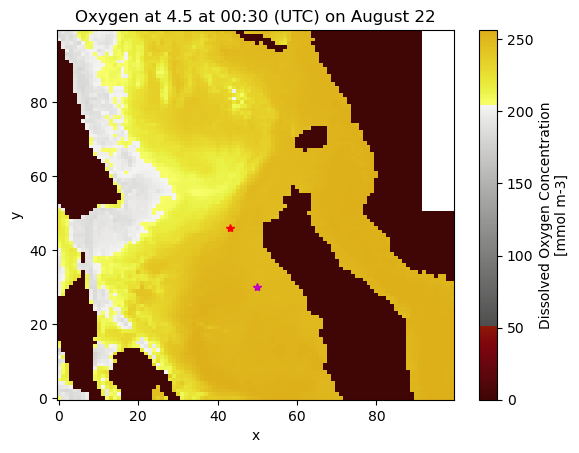

In [276]:
fig, ax = plt.subplots(1, 1)
chem.dissolved_oxygen[0, 4, 600:700, 125:225].plot(ax=ax, cmap=cm.oxy);
ax.plot(vj-125, vi-600, 'r*');
ax.plot(sj-125, si-600, 'm*');
ax.set_title('Oxygen at 4.5 at 00:30 (UTC) on August 22');

Note that the Vector point (red) is close to the front.  Front is caused by Discovery Jet water (as can be seen on the online movies)

In [14]:
box_temp = phys.votemper[0, 4, 600:700, 125:225].values

In [15]:
box_salinity = phys.vosaline[0, 4, 600:700, 125:225].values

In [16]:
box_oxy = chem.dissolved_oxygen[0, 4, 600:700, 125:225].values

In [21]:
oxy_sat = gsw.O2sol(box_salinity, box_temp, np.zeros_like(box_salinity), -125*np.ones_like(box_salinity),
            50*np.ones_like(box_salinity))  # in uM/kg

Density Error!
Oxygen saturation at Vector 254.6388320190852,
Temperature at Vector 16.11783218383789
Salinity at Vector 28.439313888549805,
Oxygen at Vector 245.25314331054688
Percent Saturation at Vector 96.31411727971056


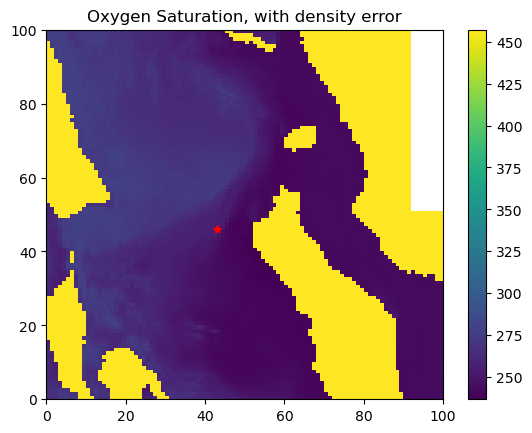

In [286]:
fig, ax = plt.subplots(1, 1)
colours = ax.pcolormesh(oxy_sat)
fig.colorbar(colours, ax=ax)
ax.plot(vj-125, vi-600, 'r*');
ax.set_title('Oxygen Saturation, with density error')
print (f'Density Error!')
print (f'Oxygen saturation at Vector {oxy_sat[vi-600, vj-125]},\nTemperature at Vector {box_temp[vi-600, vj-125]}')
print (f'Salinity at Vector {box_salinity[vi-600, vj-125]},\nOxygen at Vector {box_oxy[vi-600, vj-125]}') 
print (f'Percent Saturation at Vector {(box_oxy[vi-600, vj-125]/oxy_sat[vi-600, vj-125])*100}')

In [28]:
density = gsw.density.rho(box_salinity, box_temp, np.zeros_like(box_salinity))

Correct Version!
Oxygen saturation at Vector 259.88966326018425,
Temperature at Vector 16.11783218383789
Salinity at Vector 28.439313888549805,
Oxygen at Vector 245.25314331054688
Percent Saturation at Vector (245.25314, 94.36817926268031)
254.6388320190852 16.117832 28.439314 245.25314 0.9436817926268031


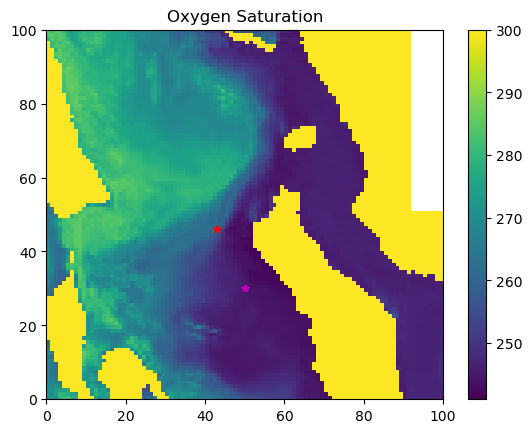

In [287]:
fig, ax = plt.subplots(1, 1)
colours = ax.pcolormesh(oxy_sat * density/1000., vmax=300)
fig.colorbar(colours, ax=ax)
ax.plot(vj-125, vi-600, 'r*');
ax.plot(sj-125, si-600, 'm*');
ax.set_title('Oxygen Saturation')
print (f'Correct Version!')
print (f'Oxygen saturation at Vector {oxy_sat[vi-600, vj-125]* density[vi-600, vj-125]/1000.},\nTemperature at Vector {box_temp[vi-600, vj-125]}')
print (f'Salinity at Vector {box_salinity[vi-600, vj-125]},\nOxygen at Vector {box_oxy[vi-600, vj-125]}') 
print (f'Percent Saturation at Vector {(box_oxy[vi-600, vj-125], box_oxy[vi-600, vj-125]/(oxy_sat[vi-600, vj-125]* density[vi-600, vj-125]/1000.)*100)}')
print (oxy_sat[vi-600, vj-125] ,
      box_temp[vi-600, vj-125],
      box_salinity[vi-600, vj-125],
      box_oxy[vi-600, vj-125], box_oxy[vi-600, vj-125]/(oxy_sat[vi-600, vj-125]* density[vi-600, vj-125]/1000.))


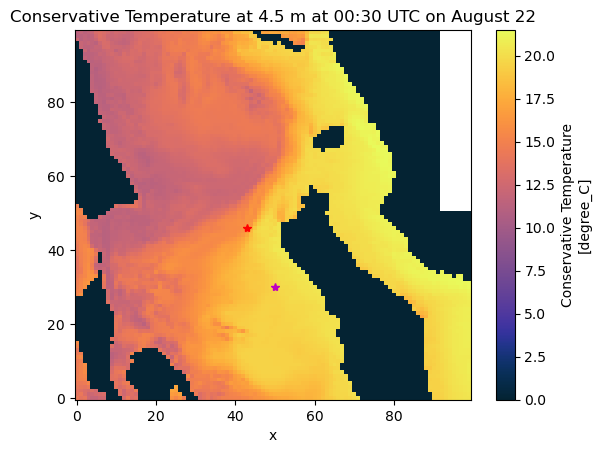

In [288]:
phys.votemper[0, 4, 600:700, 125:225].plot(cmap=cm.thermal);
plt.plot(vj-125, vi-600, 'r*');
plt.plot(sj-125, si-600, 'm*');
plt.title('Conservative Temperature at 4.5 m at 00:30 UTC on August 22');

In [69]:
box_pt = gsw.pt_from_CT(box_salinity, box_temp)

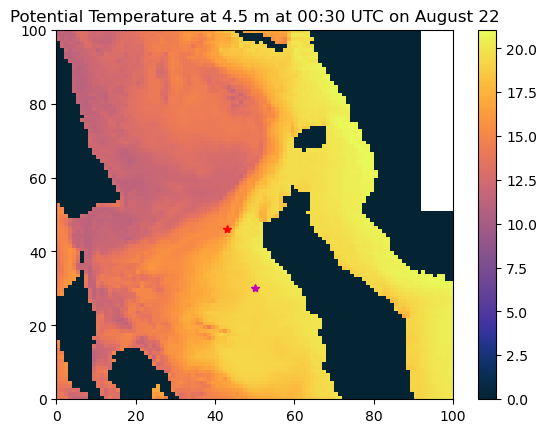

In [289]:
plt.pcolormesh(box_pt, cmap=cm.thermal)
plt.colorbar()
plt.plot(vj-125, vi-600, 'r*')
plt.plot(sj-125, si-600, 'm*')
plt.title('Potential Temperature at 4.5 m at 00:30 UTC on August 22');

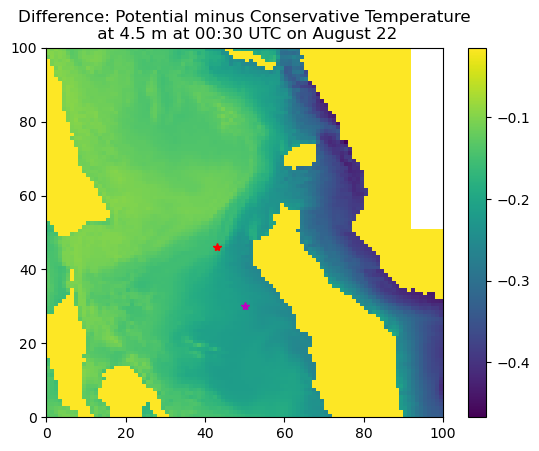

In [290]:
plt.pcolormesh(box_pt - box_temp)
plt.colorbar()
plt.plot(vj-125, vi-600, 'r*')
plt.plot(sj-125, si-600, 'm*')
plt.title('Difference: Potential minus Conservative Temperature\n at 4.5 m at 00:30 UTC on August 22');

In [35]:
oxy_sat_pt = gsw.O2sol(box_salinity, box_pt, np.zeros_like(box_salinity), -125*np.ones_like(box_salinity),
            50*np.ones_like(box_salinity)) 

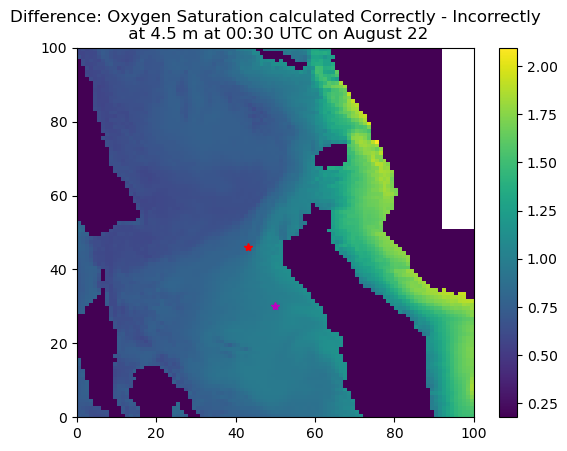

In [291]:
plt.pcolormesh(oxy_sat_pt - oxy_sat)
plt.colorbar()
plt.plot(vj-125, vi-600, 'r*');
plt.plot(sj-125, si-600, 'm*')
plt.title('Difference: Oxygen Saturation calculated Correctly - Incorrectly\n at 4.5 m at 00:30 UTC on August 22');


In [314]:
def figure_cross(var, var_name, ds=biol):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    ds[var][0, 0:20, 600:700, vj].plot(ax=axs[0], yincrease=False)
    axs[0].plot(vi-600, 4.5, 'r*');
    axs[0].set_title('Along Strait vertical Cross-section at Vector Point\n at 00:30 UTC on August 22')
        
    ds[var][0, 0:20, 600:700, sj].plot(ax=axs[1], yincrease=False)
    axs[1].plot(si-600, 4.5, 'm*');
    axs[1].set_title('Along Strait vertical Cross-section at "Susan" Point\n at 00:30 UTC on August 22')
    
    for ax in axs:
        ax.set_xlabel('Y-Grid point, approx 500 m apart')
    
    fig.suptitle(f'{var_name} Concentration', fontsize=14, y=1);
    
    axs[0].text(0, 27, 'Note that the Vector Point is in the front but "Susan" is in the centre of the water mass');

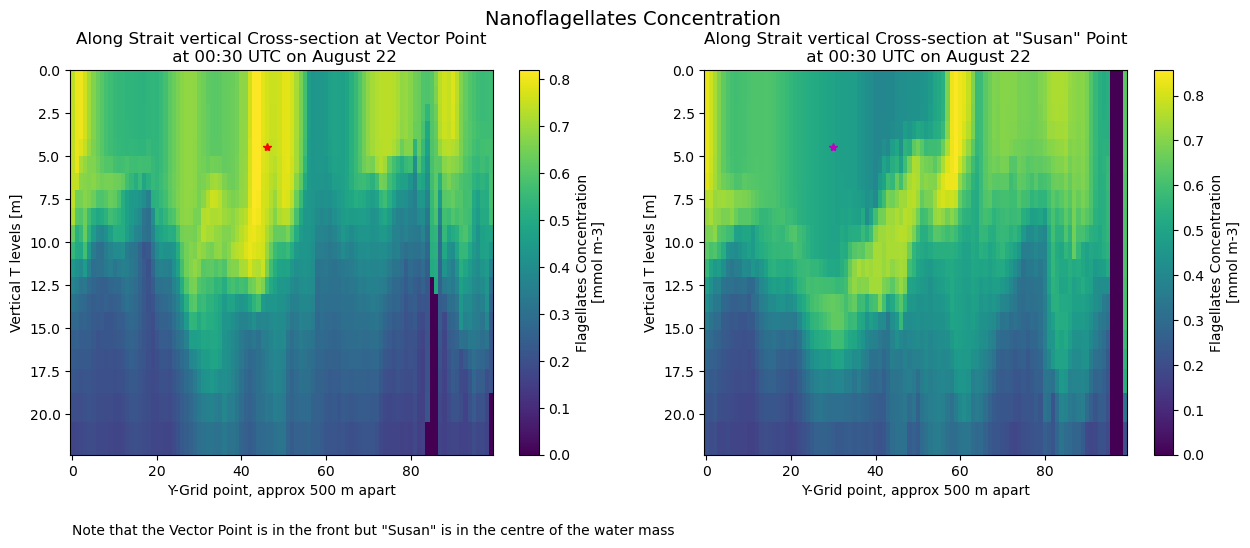

In [308]:
figure_cross('flagellates', 'Nanoflagellates')

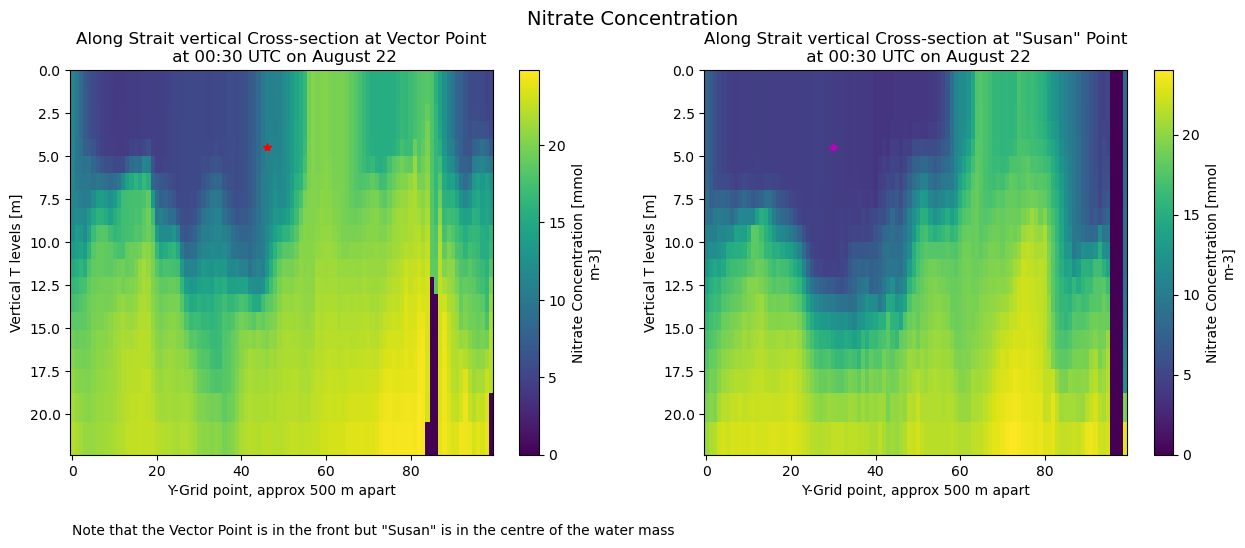

In [309]:
figure_cross('nitrate', 'Nitrate')

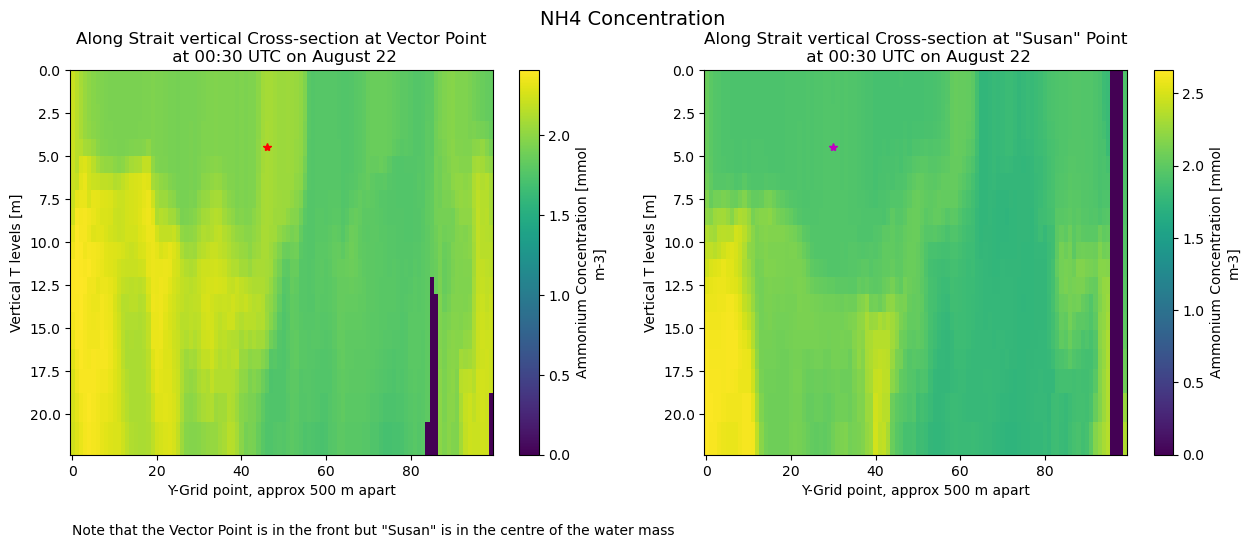

In [310]:
figure_cross('ammonium', 'NH4')

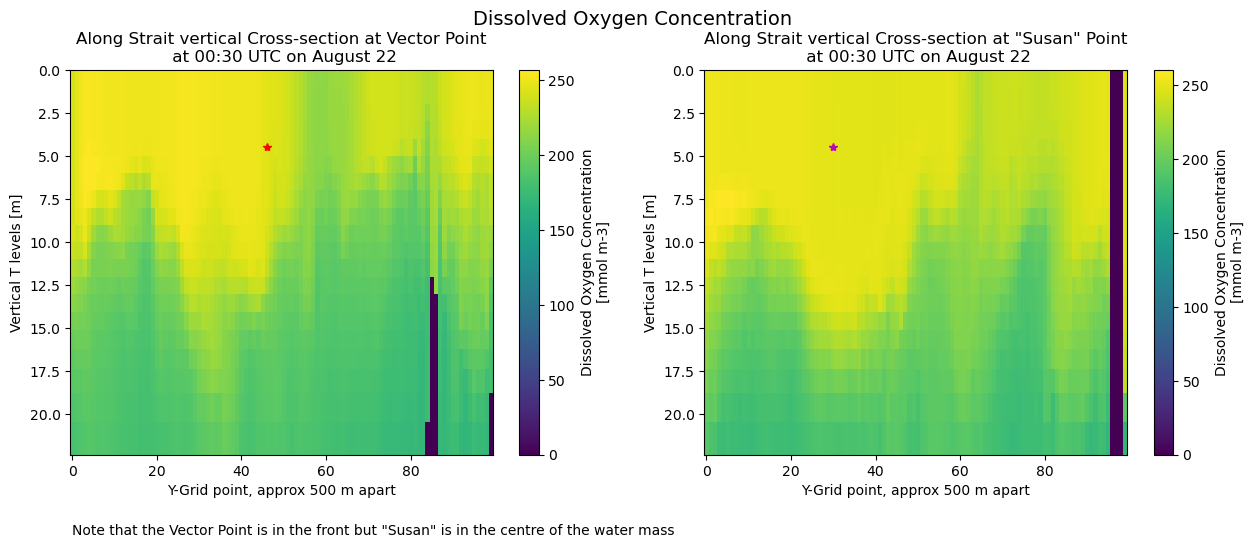

In [315]:
figure_cross('dissolved_oxygen', 'Dissolved Oxygen', ds=chem)

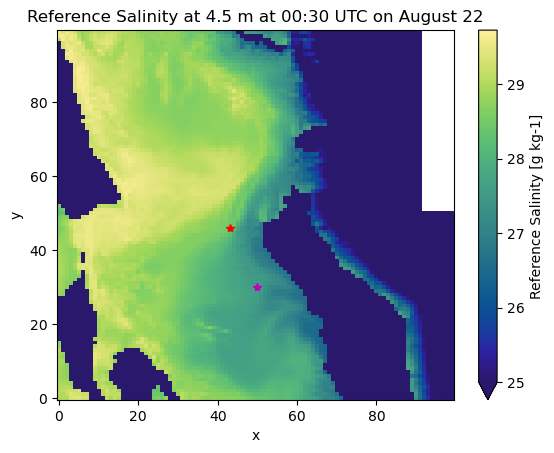

In [316]:
phys.vosaline[0, 4, 600:700, 125:225].plot(cmap=cm.haline, vmin=25);
plt.plot(vj-125, vi-600, 'r*');
plt.plot(sj-125, si-600, 'm*')
plt.title('Reference Salinity at 4.5 m at 00:30 UTC on August 22');

0.13217002493997126


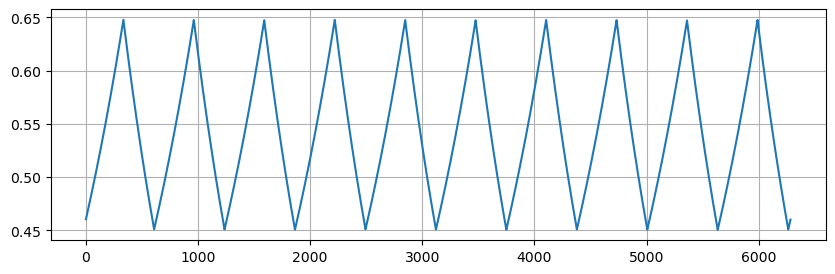

In [223]:
# A toy model: daily growth + steady decay (call resp), does changing resp impact the size of the daily zig-zag
# answer is no!
dt = 0.01
time = np.arange(0, 10*2*np.pi, dt)
growth = np.ones_like(time)
growth[np.sin(time) < -0.2] = 0
growth[np.sin(time) > -0.2] = 1.55 * 0.95 /(2*np.pi)
print (growth.mean())
resp = 0.83 * np.ones_like(time) / (2*np.pi)
phyto = 0.46 * np.ones_like(time)
for it, tt in enumerate(time[1:]):
    phyto[it] = phyto[it-1] + dt * (growth[it] - resp[it]) * phyto[it-1]
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(phyto);
ax.grid();

0.1795178606994516


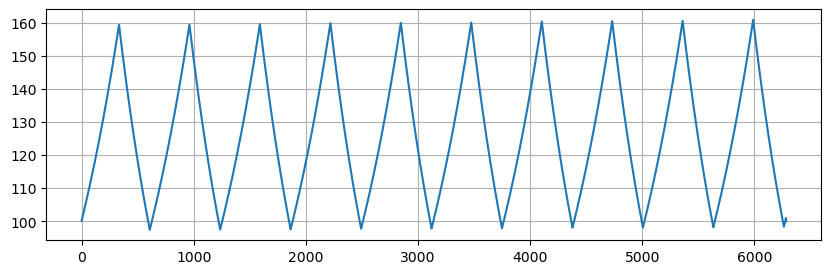

In [209]:
# Growth set to 2
dt = 0.01
time = np.arange(0, 10*2*np.pi, dt)
growth = np.ones_like(time)
growth[np.sin(time) < -0.2] = 0
growth[np.sin(time) > -0.2] = 2 /(2*np.pi)
print (growth.mean())
resp = 1.126 * np.ones_like(time) / (2*np.pi)
phyto = 100 * np.ones_like(time)
for it, tt in enumerate(time[1:]):
    phyto[it] = phyto[it-1] + dt * (growth[it] - resp[it]) * phyto[it-1]
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(phyto);
ax.grid();

In [394]:
def plot_timeseries(var, var_name, piece, note=True):
    fig, ax = plt.subplots(1, 1, figsize=(15, 5))
    piece[0][var][:, 4, vi, vj].plot(ax=ax, label='Vector Point')
    piece[0][var][:, 4, si, sj].plot(ax=ax, c='tab:purple', label='"Susan Point"')
    piece[1][var][:, 4, vi, vj].plot(ax=ax, c='tab:blue')
    piece[1][var][:, 4, si, sj].plot(ax=ax, c='tab:purple')
    piece[2][var][:, 4, vi, vj].plot(ax=ax, c='tab:blue')
    piece[2][var][:, 4, si, sj].plot(ax=ax, c='tab:purple')
    piece[3][var][:, 4, vi, vj].plot(ax=ax, c='tab:blue')
    piece[3][var][:, 4, si, sj].plot(ax=ax, c='tab:purple')
    ax.set_title(f'{var_name} Concentration at 4.5 m Depth')
    ax.legend()
    ax.set_xlabel('Date and Hour in 2024');
    if note:
        ax.text(0.05, -0.25, 'Note the smoother, more regular time series at "Susan" than at the Vector Point', 
                transform=ax.transAxes);
    return ax

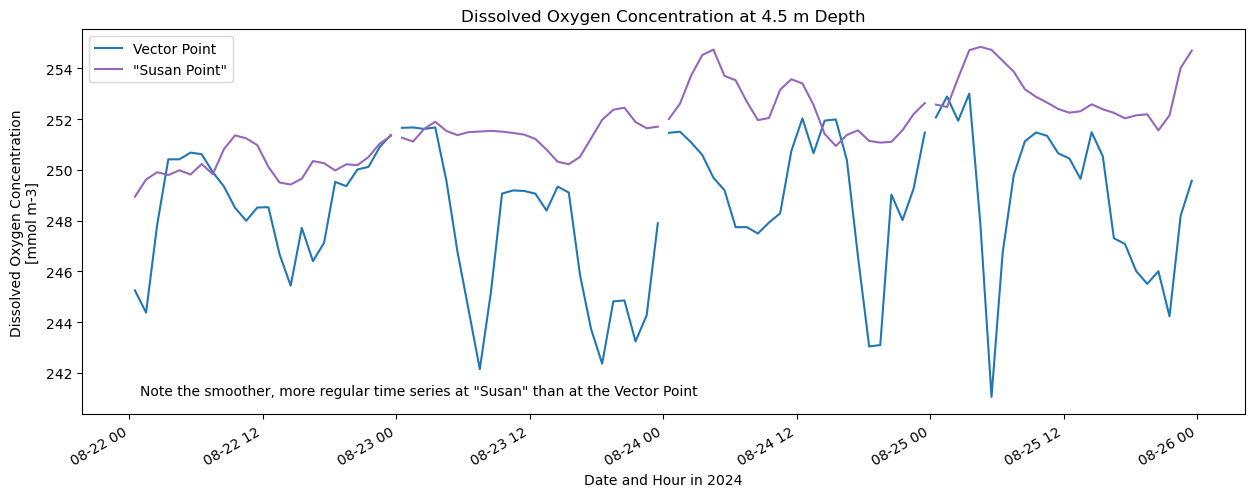

In [348]:
plot_timeseries('dissolved_oxygen', 'Dissolved Oxygen', [chem, chem23, chem24, chem25])

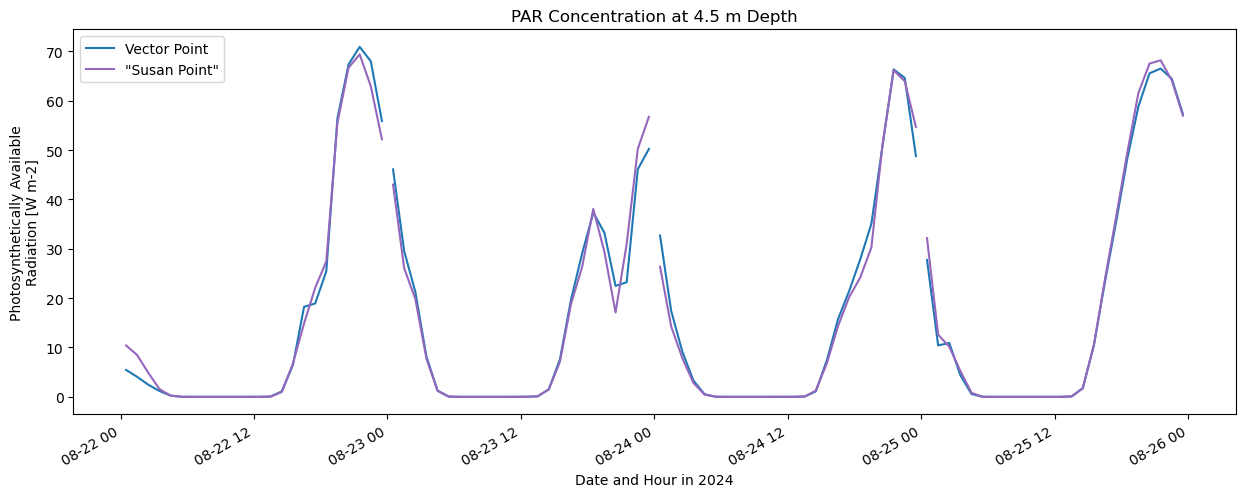

In [337]:
plot_timeseries('PAR', 'PAR', [chem, chem23, chem24, chem25], note=False)

**NEMO calculation of Light Limitation**

zz_plank_growth_light(ji,jj,jk) = &
                       (1.0_wp - exp(-zz_I_par(ji,jj,jk) *zz_PE_a) ) * &
                       (exp(-zz_I_par(ji,jj,jk) *zz_PE_b )) * zz_PE_f

zz_PE_alpha_flag = zz_PE_a_flag * zz_rate_R_flag
zz_PE_beta_flag = zz_PE_alpha_flag/(exp(zz_PE_Iopt_flag * zz_PE_alpha_flag/zz_rate_R_flag)-1._wp)
zz_PE_b_flag = zz_PE_beta_flag/zz_rate_R_flag
zz_PE_f_flag=(zz_PE_alpha_flag+zz_PE_beta_flag)/zz_PE_alpha_flag * ((zz_PE_alpha_flag+zz_PE_beta_flag)/     
             zz_PE_beta_flag)**(zz_PE_beta_flag/zz_PE_alpha_flag) 

                       
zz_PE_a
zz_PE_b
zz_PE_f

0.38 0.00019026676398220313
0.00019026676398220313 1.0043151957399252


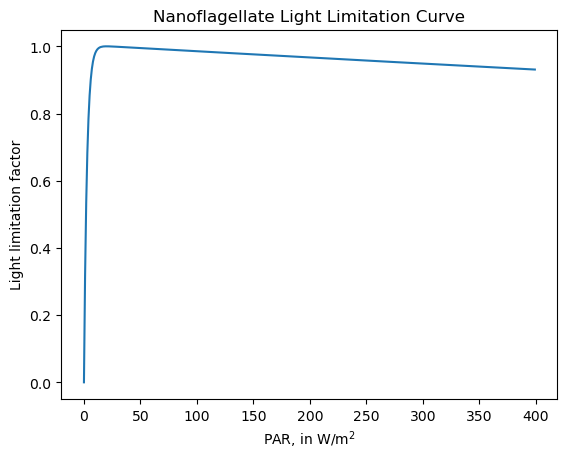

In [340]:
# Calculate the Light Limitation curve for Nanoflagellates
# Values from Code
PE_a_flag = 0.38 # 1/(W/m2)
PE_Iopt_flag = 20 # W/kg
rate_R_flag = 1 #1.8e-5

# Calculation following above
PE_alpha_flag = PE_a_flag * rate_R_flag
PE_beta_flag = PE_alpha_flag / (np.exp(PE_Iopt_flag * PE_a_flag) - 1)

PE_b_flag = PE_beta_flag / rate_R_flag

PE_f_flag = ((PE_alpha_flag + PE_beta_flag) / PE_alpha_flag 
                    * ((PE_alpha_flag + PE_beta_flag)/PE_beta_flag)**(PE_beta_flag/PE_alpha_flag) )

print (PE_alpha_flag, PE_beta_flag)
print (PE_b_flag, PE_f_flag)

def light_limitation(light):
    growth = ((1 - np.exp(-light * PE_a_flag) ) * 
                       (np.exp(-light * PE_b_flag )) * PE_f_flag)
    return growth
light = np.arange(0, 400, 1)
plt.plot(light, light_limitation(light));
plt.ylabel('Light limitation factor')
plt.xlabel('PAR, in W/m$^2$');
plt.title('Nanoflagellate Light Limitation Curve');

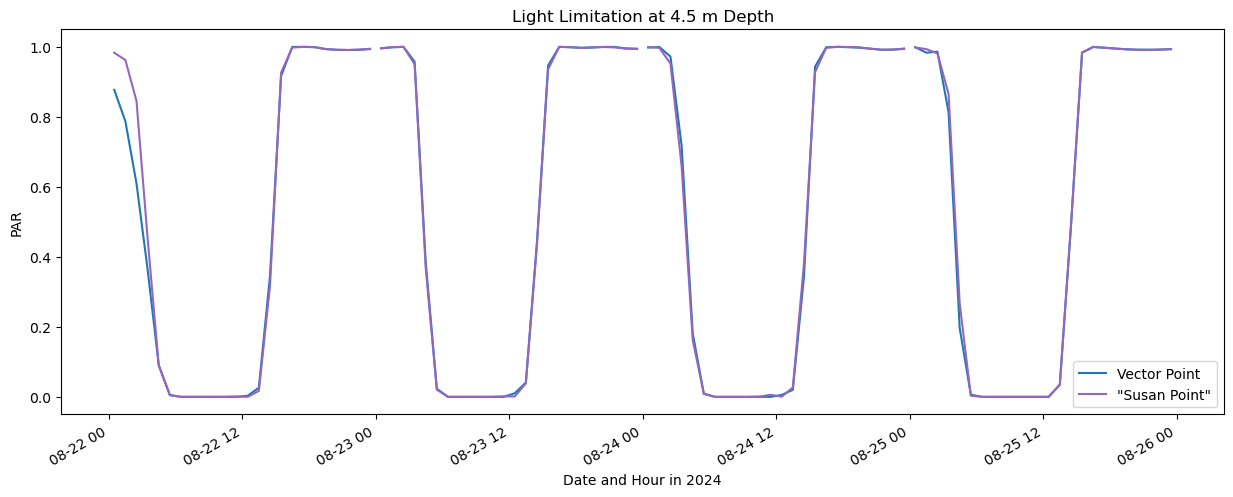

In [341]:
var = 'PAR'
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
light_limitation(chem[var][:, 4, vi, vj]).plot(ax=ax, label='Vector Point')
light_limitation(chem[var][:, 4, si, sj]).plot(ax=ax, c='tab:purple', label='"Susan Point"')
light_limitation(chem23[var][:, 4, vi, vj]).plot(ax=ax, c='tab:blue')
light_limitation(chem23[var][:, 4, si, sj]).plot(ax=ax, c='tab:purple')
light_limitation(chem24[var][:, 4, vi, vj]).plot(ax=ax, c='tab:blue')
light_limitation(chem24[var][:, 4, si, sj]).plot(ax=ax, c='tab:purple');
light_limitation(chem25[var][:, 4, vi, vj]).plot(ax=ax, c='tab:blue')
light_limitation(chem25[var][:, 4, si, sj]).plot(ax=ax, c='tab:purple');

ax.set_title(f'Light Limitation at 4.5 m Depth')
ax.legend()
ax.set_xlabel('Date and Hour in 2024');
    



In [344]:
print (f'Mean light limitation over last day {light_limitation(chem25[var][:, 4, si, sj]).mean().values}')

Mean light limitation over last day 0.5654289126396179


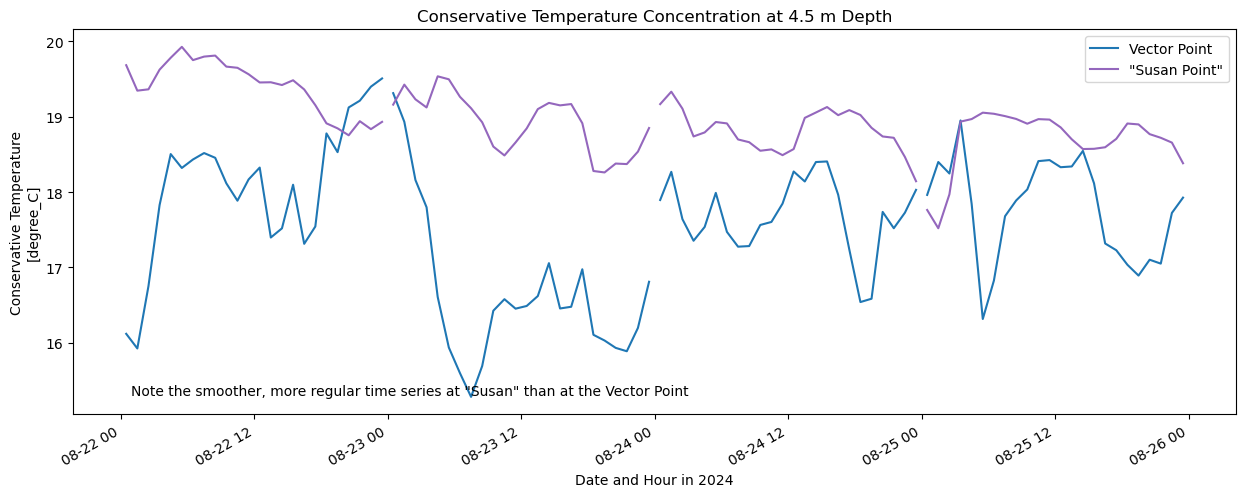

In [349]:
plot_timeseries('votemper', 'Conservative Temperature', [phys, phys23, phys24, phys25], note=True)

**Nanoflagellate Temperature Limitation from NEMO Code**

zz_Rmax(:,:,:)= zz_rate_R * tgfunc(:,:,:) &
            * min(max(zz_rate_maxtemp - zz_temp, 0.0_wp), &
                  zz_rate_temprange) / &
            (zz_rate_temprange + epsilon(zz_rate_temprange))

where tgfunc = Q10

zz_rate_maxtemp = 31
zz_rate_temprange = 13

In [365]:
def Q10(temp):
    return np.exp(0.07*(temp-20))
def temp_limit(temp):
    maxtemp = 31
    temprange = 13
    limit = maxtemp - temp
    limit[limit < 0] = 0
    limit[limit > temprange] = temprange
    return Q10(temp) * limit / temprange

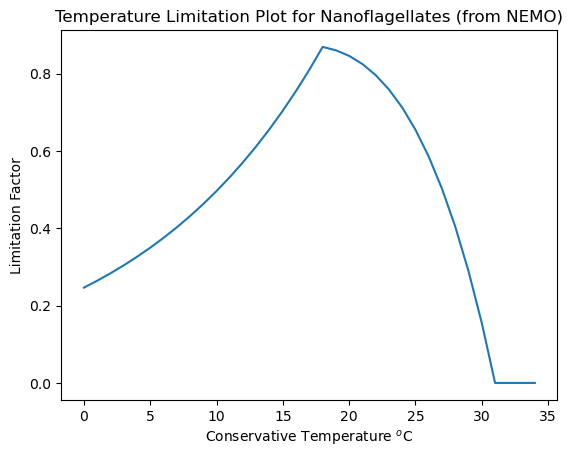

In [366]:
temps = np.arange(0, 35, 1)
fig, ax = plt.subplots(1, 1)
ax.plot(temps, temp_limit(temps))
ax.set_title('Temperature Limitation Plot for Nanoflagellates (from NEMO)')
ax.set_ylabel('Limitation Factor')
ax.set_xlabel('Conservative Temperature $^o$C');

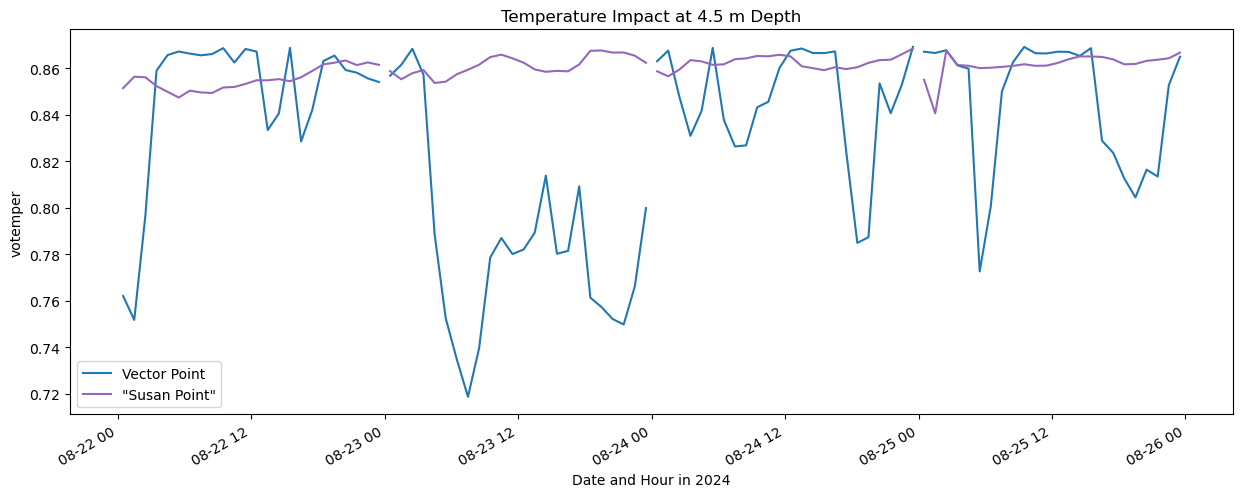

In [367]:
var = 'votemper'
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
temp_limit(phys[var][:, 4, vi, vj]).plot(ax=ax, label='Vector Point')
temp_limit(phys[var][:, 4, si, sj]).plot(ax=ax, c='tab:purple', label='"Susan Point"')
temp_limit(phys23[var][:, 4, vi, vj]).plot(ax=ax, c='tab:blue')
temp_limit(phys23[var][:, 4, si, sj]).plot(ax=ax, c='tab:purple')
temp_limit(phys24[var][:, 4, vi, vj]).plot(ax=ax, c='tab:blue')
temp_limit(phys24[var][:, 4, si, sj]).plot(ax=ax, c='tab:purple');
temp_limit(phys25[var][:, 4, vi, vj]).plot(ax=ax, c='tab:blue')
temp_limit(phys25[var][:, 4, si, sj]).plot(ax=ax, c='tab:purple');

ax.set_title(f'Temperature Impact at 4.5 m Depth')
ax.legend()
ax.set_xlabel('Date and Hour in 2024');

In [368]:
print (f'Mean temperature impact over last day {temp_limit(phys25[var][:, 4, si, sj]).mean().values}')

Mean temperature impact over last day 0.8615530133247375


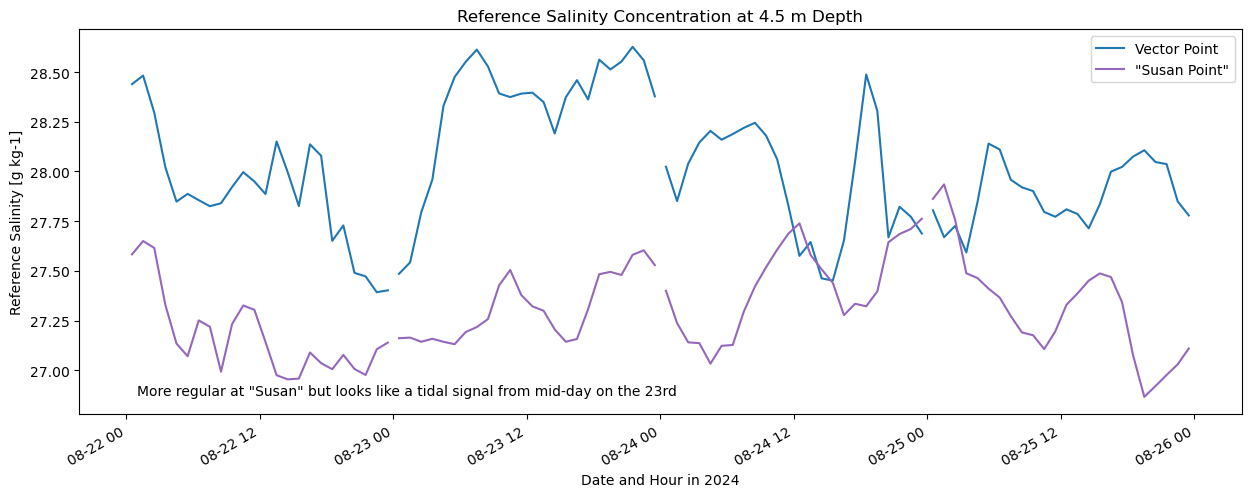

In [371]:
ax = plot_timeseries('vosaline', 'Reference Salinity', [phys, phys23, phys24, phys25], note=False)
ax.text(0.05, 0.05, 'More regular at "Susan" but looks like a tidal signal from mid-day on the 23rd',
        transform=ax.transAxes);

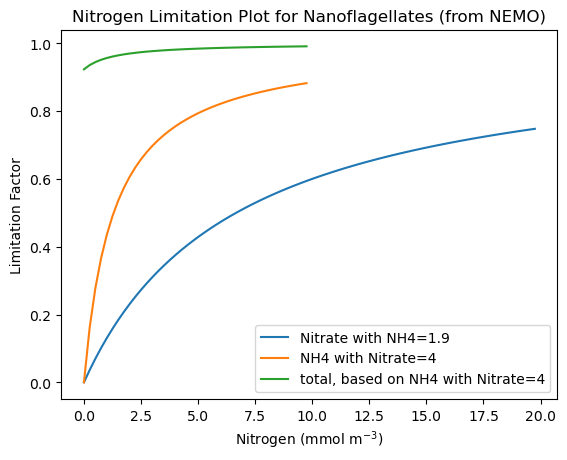

In [385]:
#for nanoflagellates
def nitrogen_limit(nitrate, nh4):
    k, Kappa = 0.3, 0.1
    
    nitrate_limit = k * nitrate / (Kappa + k * nitrate + nh4)
    nh4_limit = nh4 / (Kappa + k * nitrate + nh4)
    LiN = nh4_limit + nitrate_limit

    return nitrate_limit, nh4_limit, LiN

nitrate = np.arange(0, 20, 0.25)
ammonium = 1.9
nitrate_limit, na, na2 = nitrogen_limit(nitrate, ammonium)
nitrate_base = 4
nh4 = np.arange(0, 10, 0.25)
na, nh4_limit, LiN = nitrogen_limit(nitrate_base, nh4)

fig, ax = plt.subplots(1, 1)
ax.plot(nitrate, nitrate_limit, label='Nitrate with NH4=1.9')
ax.plot(nh4, nh4_limit, label='NH4 with Nitrate=4')
ax.plot(nh4, LiN, label='total, based on NH4 with Nitrate=4')
ax.set_title('Nitrogen Limitation Plot for Nanoflagellates (from NEMO)')
ax.set_ylabel('Limitation Factor')
ax.set_xlabel('Nitrogen (mmol m$^{-3}$)')
ax.legend();

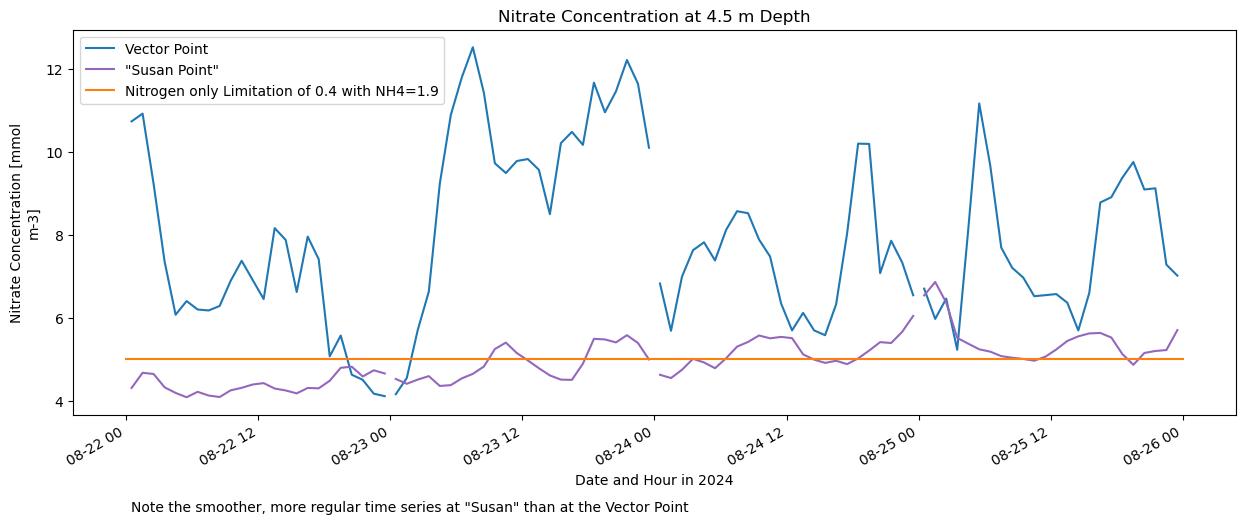

In [395]:
ax = plot_timeseries('nitrate', 'Nitrate', [biol, biol23, biol24, biol25], note=True)

ax.plot([datetime.datetime(2024, 8, 22), datetime.datetime(2024, 8, 26)], 
        [5, 5], label='Nitrogen only Limitation of 0.4 with NH4=1.9');
ax.legend();

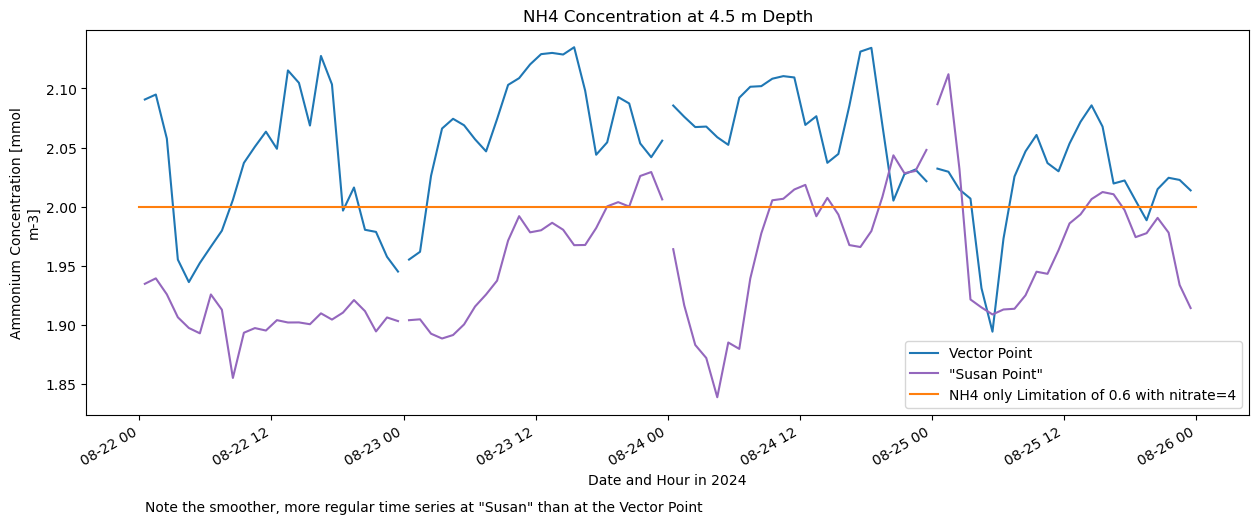

In [397]:
ax = plot_timeseries('ammonium', 'NH4', [biol, biol23, biol24, biol25], note=True)

ax.plot([datetime.datetime(2024, 8, 22), datetime.datetime(2024, 8, 26)], 
        [2, 2], label='NH4 only Limitation of 0.6 with nitrate=4');
ax.legend();

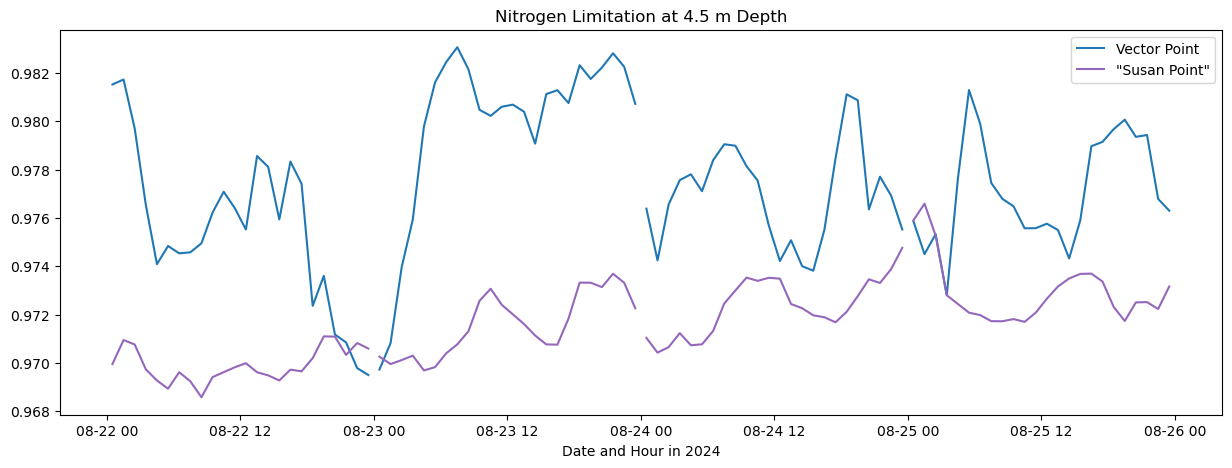

In [400]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))

na, na, LiN = nitrogen_limit(biol.nitrate[:, 4, vi, vj], biol.ammonium[:, 4, vi, vj])
ax.plot(biol.time_counter, LiN, label='Vector Point')
na, na, LiN = nitrogen_limit(biol.nitrate[:, 4, si, sj], biol.ammonium[:, 4, si, sj])
ax.plot(biol.time_counter, LiN, c='tab:purple', label='"Susan Point"')

for ds in [biol23, biol24, biol25]:
    na, na, LiN = nitrogen_limit(ds.nitrate[:, 4, vi, vj], ds.ammonium[:, 4, vi, vj])
    ax.plot(ds.time_counter, LiN, c='tab:blue')
    na, na, LiN = nitrogen_limit(ds.nitrate[:, 4, si, sj], ds.ammonium[:, 4, si, sj])
    ax.plot(ds.time_counter, LiN, c='tab:purple')

ax.set_title(f'Nitrogen Limitation at 4.5 m Depth')
ax.legend()
ax.set_xlabel('Date and Hour in 2024');

In [407]:
print (f'Mean nitrogen impact over last day {LiN.mean().values}')

Mean nitrogen impact over last day 0.9729469418525696


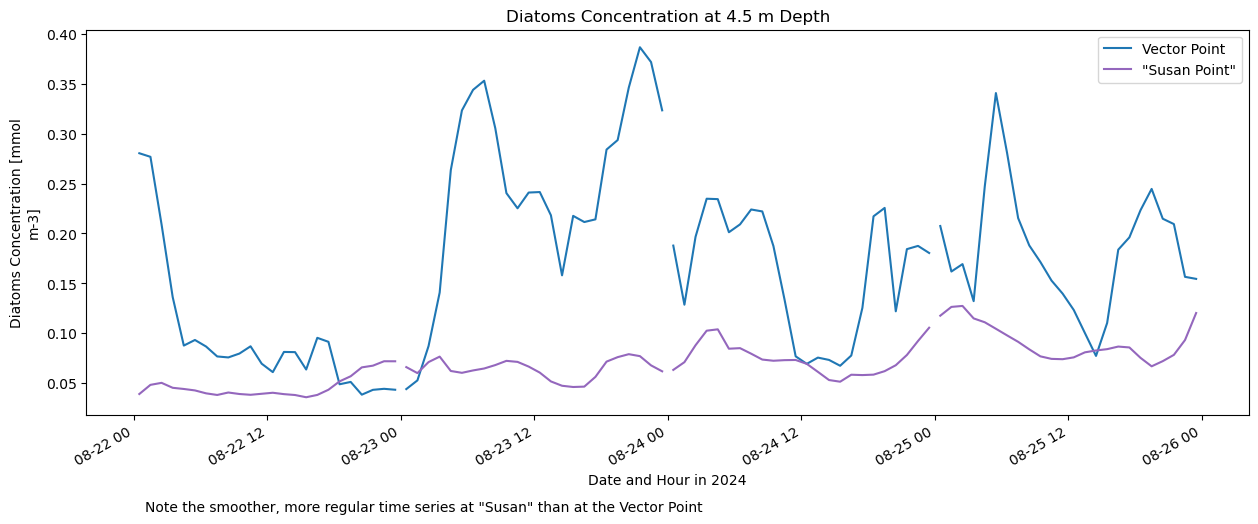

In [401]:
ax = plot_timeseries('diatoms', 'Diatoms', [biol, biol23, biol24, biol25], note=True)

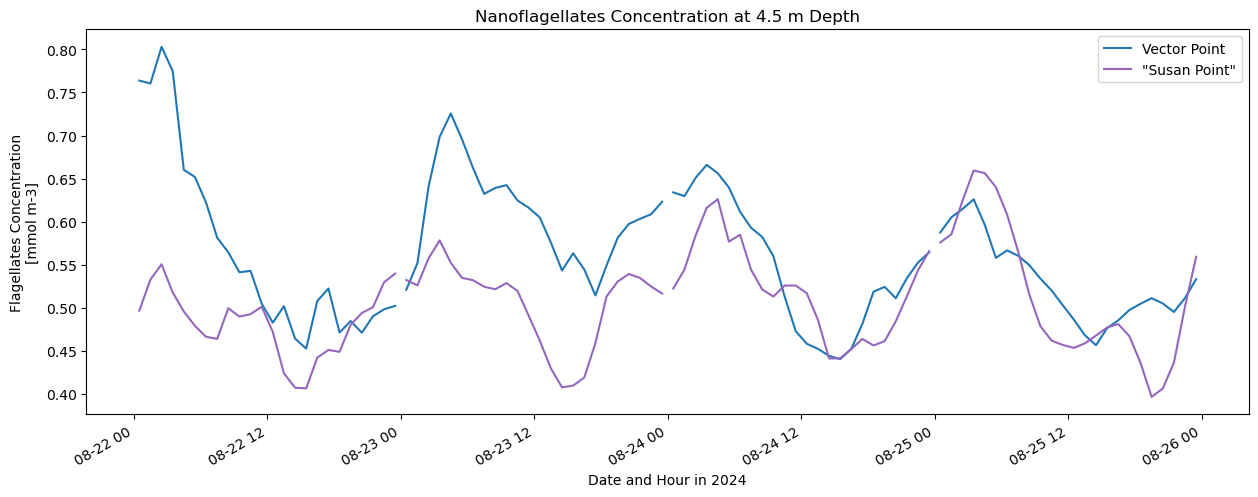

In [404]:
ax = plot_timeseries('flagellates', 'Nanoflagellates', [biol, biol23, biol24, biol25], note=False)

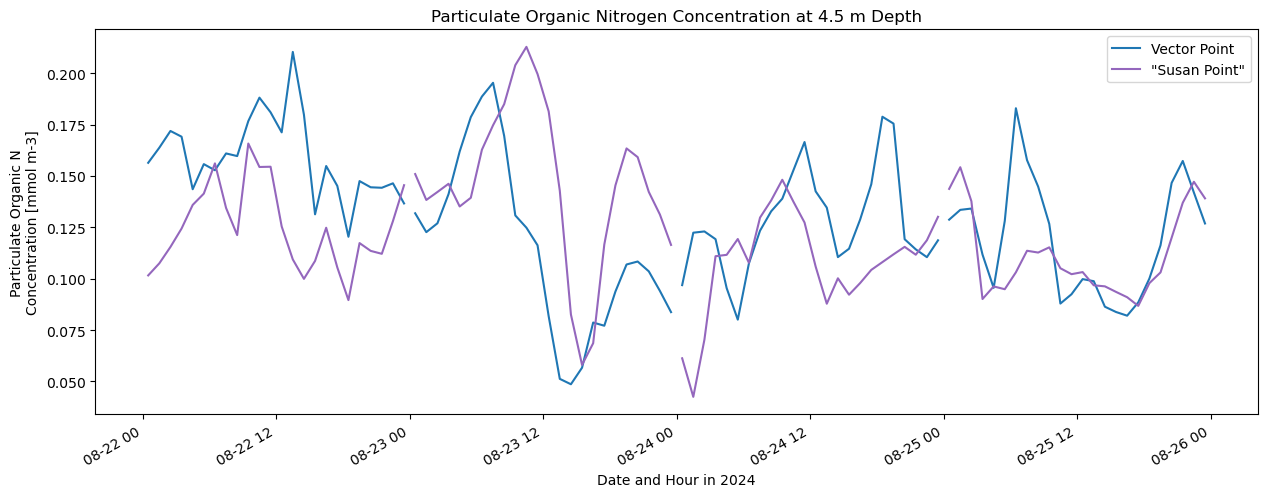

In [405]:
ax = plot_timeseries('particulate_organic_nitrogen', 'Particulate Organic Nitrogen', 
                     [biol, biol23, biol24, biol25], note=False)

In [406]:
var = ['diatoms', 'flagellates', 'particulate_organic_nitrogen']
fields = np.zeros((8, 24))
for vv in var:
    fields[0] = fields[0] + biol[vv][:, 4, vi, vj] 
    fields[1] = fields[1] + biol[vv][:, 4, si, sj]
    fields[2] = fields[2] + biol23[vv][:, 4, vi, vj]
    fields[3] = fields[3] + biol23[vv][:, 4, si, sj]
    fields[4] = fields[4] + biol24[vv][:, 4, vi, vj]
    fields[5] = fields[5] + biol24[vv][:, 4, si, sj]
    fields[6] = fields[6] + biol25[vv][:, 4, vi, vj]
    fields[7] = fields[7] + biol25[vv][:, 4, si, sj]

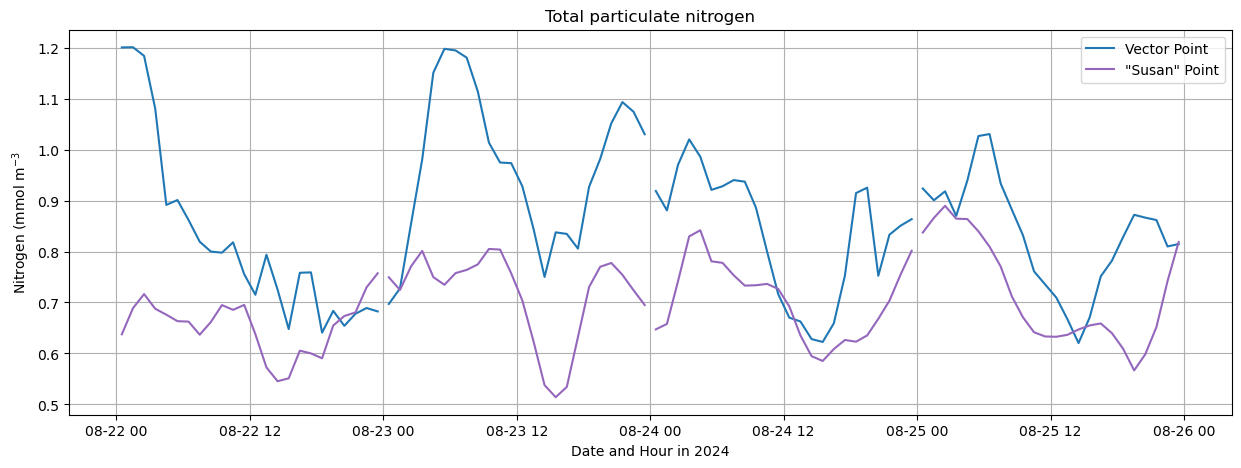

In [408]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(biol.time_counter, fields[0], label='Vector Point')
ax.plot(biol.time_counter, fields[1], c='tab:purple', label='"Susan" Point')
ax.plot(biol23.time_counter, fields[2], c='tab:blue')
ax.plot(biol23.time_counter, fields[3], c='tab:purple')
ax.plot(biol24.time_counter, fields[4], c='tab:blue')
ax.plot(biol24.time_counter, fields[5], c='tab:purple')
ax.plot(biol25.time_counter, fields[6], c='tab:blue')
ax.plot(biol25.time_counter, fields[7], c='tab:purple')
ax.grid();

ax.set_title(f'Total particulate nitrogen')
ax.set_ylabel('Nitrogen (mmol m$^{-3}$')
ax.legend()
ax.set_xlabel('Date and Hour in 2024');

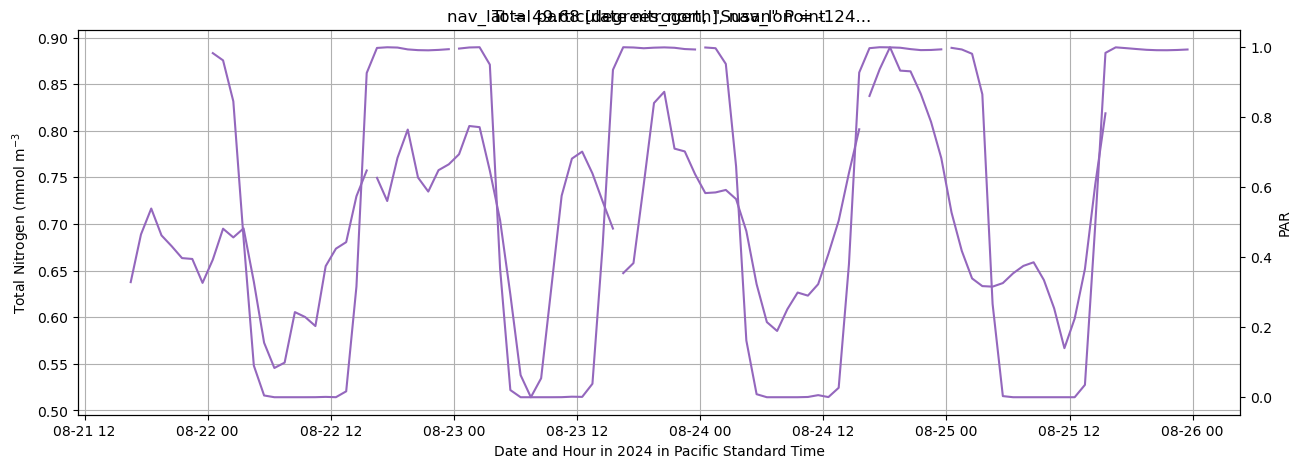

In [415]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
shift_time = np.timedelta64(-8, 'h')
ax.plot(biol.time_counter+shift_time, fields[1], c='tab:purple', label='"Susan" Point')
ax.plot(biol23.time_counter+shift_time, fields[3], c='tab:purple')
ax.plot(biol24.time_counter+shift_time, fields[5], c='tab:purple')
ax.plot(biol25.time_counter+shift_time, fields[7], c='tab:purple')
ax.grid();

ax.set_title(f'Total particulate nitrogen, "Susan" Point')
ax.set_ylabel('Total Nitrogen (mmol m$^{-3}$')
ax.set_xlabel('Date and Hour in 2024 in Pacific Standard Time');

ax2 = ax.twinx()
var = 'PAR'
light_limitation(chem[var][:, 4, si, sj]).plot(ax=ax2, c='tab:purple')
light_limitation(chem23[var][:, 4, si, sj]).plot(ax=ax2, c='tab:purple')
light_limitation(chem24[var][:, 4, si, sj]).plot(ax=ax2, c='tab:purple');
light_limitation(chem25[var][:, 4, si, sj]).plot(ax=ax2, c='tab:purple');

In [416]:
chem25[var][:, 4, si, sj].shape

(24,)

In [424]:
dark = np.ones((24*4, 5))
ic = 0
for cc in [chem[var], chem23[var], chem24[var], chem25[var]]:
    dark[ic:ic+24, 0] = light_limitation(cc[:, 4, si, sj])
    for iv in range(1, 5):
        dark[ic:ic+24, iv] = dark[ic:ic+24, 0]
    ic = ic + 24

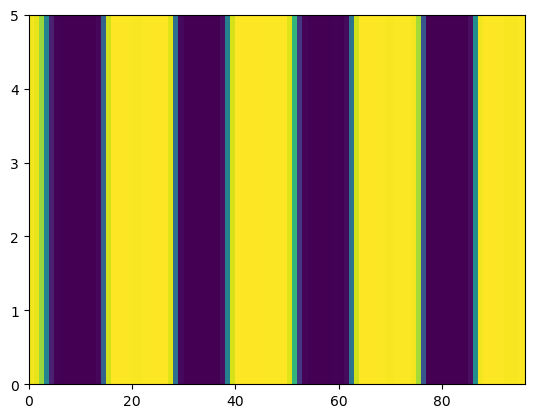

In [426]:
plt.pcolormesh(dark.transpose())

In [428]:
times = np.concatenate([biol.time_counter+shift_time, biol23.time_counter+shift_time,
                biol24.time_counter+shift_time, biol25.time_counter+shift_time])

Morning Low on 22nd at 2024-08-22T06:30:00.000000000 of 0.5454998202621937
Evening High on 22nd at 2024-08-22T19:30:00.000000000 of 0.8012590259313583
Difference of 0.25575920566916466 mmol N /m3
Normalized Difference of 0.029192858629345002 /hr 

Morning Low on 23nd at 2024-08-22T07:30:00.000000000 of 0.55126628652215
Evening High on 23nd at 2024-08-23T20:30:00.000000000 of 0.8417689204216003
Difference of 0.32762714102864265 mmol N /m3
Normalized Difference of 0.03581701582320979 /hr
Morning Low on 24th at 2024-08-22T07:30:00.000000000 of 0.5852122008800507
Evening High on 24th at 2024-08-23T18:30:00.000000000 of 0.889582559466362
Difference of 0.30437035858631134 mmol N /m3
Normalized Difference of 0.038611908518879565 /hr


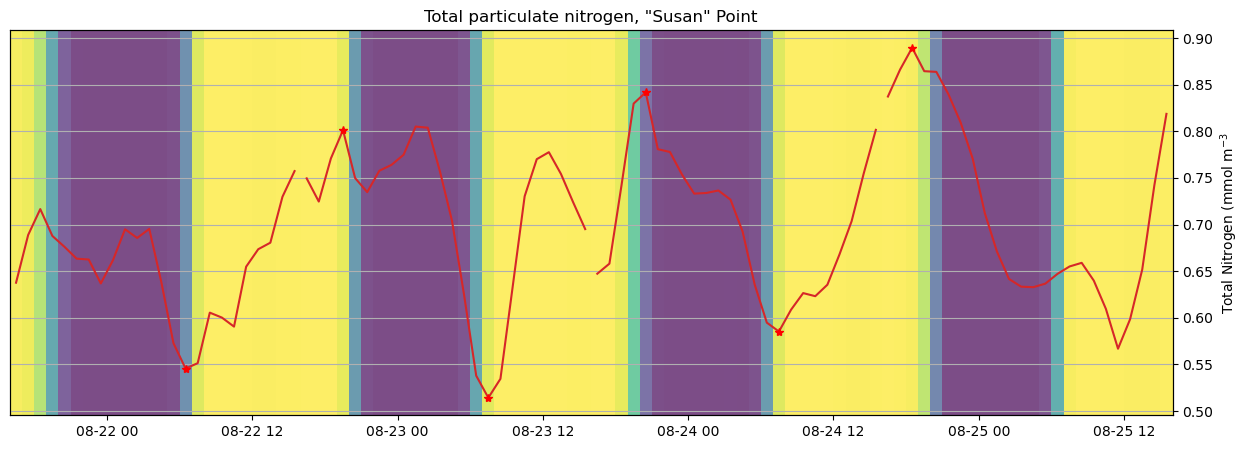

In [524]:
fig, ax2 = plt.subplots(1, 1, figsize=(15, 5))

ax2.pcolormesh(times, np.arange(5), dark.transpose(), shading='nearest', alpha=0.7);
ax2.set_yticks([])

ax = ax2.twinx()
ax.plot(biol.time_counter+shift_time, fields[1], c='tab:red', label='"Susan" Point')
ax.plot(biol23.time_counter+shift_time, fields[3], c='tab:red')
ax.plot(biol24.time_counter+shift_time, fields[5], c='tab:red')
ax.plot(biol25.time_counter+shift_time, fields[7], c='tab:red')
ax.grid();

ax.set_title(f'Total particulate nitrogen, "Susan" Point')
ax.set_ylabel('Total Nitrogen (mmol m$^{-3}$')
ax.set_xlabel('Date and Hour in 2024 in Pacific Standard Time');

it1 = 14
print (f'Morning Low on 22nd at {times[it1]} of {fields[1, it1]}')
ax.plot(times[it1], fields[1, it1], 'r*')
jt1 = 3
print (f'Evening High on 22nd at {times[jt1+24]} of {fields[3, jt1]}')
ax.plot(times[jt1+24], fields[3, jt1], 'r*')
print (f'Difference of {fields[3, jt1] - fields[1, it1]} mmol N /m3')
average4 = np.concatenate([fields[1, it1:], fields[3, :jt1+1]]).mean()
print (f'Normalized Difference of {(fields[3, jt1] - fields[1, it1])/average4/(jt1-it1+24)} /hr \n')

it2 = 15
print (f'Morning Low on 23nd at {times[it2]} of {fields[1, it2]}')
ax.plot(times[it2+24], fields[3, it2], 'r*')
jt2 = 4
print (f'Evening High on 23nd at {times[jt2+48]} of {fields[5, jt2]}')
ax.plot(times[jt2+48], fields[5, jt2], 'r*')
print (f'Difference of {fields[5, jt2] - fields[3, it2]} mmol N /m3')
average5 = np.concatenate([fields[3, it2:], fields[5, :jt2+1]]).mean()
print (f'Normalized Difference of {(fields[5, jt2] - fields[3, it2])/average5/(jt2-it2+24)} /hr')

it3 = 15
print (f'Morning Low on 24th at {times[it3]} of {fields[5, it3]}')
ax.plot(times[it3+48], fields[5, it3], 'r*')
jt3 = 2
print (f'Evening High on 24th at {times[jt3+48]} of {fields[7, jt3]}')
ax.plot(times[jt3+72], fields[7, jt3], 'r*')
print (f'Difference of {fields[7, jt3] - fields[5, it3]} mmol N /m3')
average6 = np.concatenate([fields[5, it3:], fields[7, :jt3+1]]).mean()
print (f'Normalized Difference of {(fields[7, jt3] - fields[5, it3])/average6/(jt3-it3+24)} /hr')

mean_growth = [(fields[3, jt1] - fields[1, it1])/(jt1-it1+24) * 24 /average4,
               (fields[5, jt2] - fields[3, it2])/(jt2-it2+24) * 24 /average5,
               (fields[7, jt3] - fields[5, it3])/(jt3-it3+24) * 24 /average6]

In [525]:
field = np.concatenate([fields[1], fields[3], fields[5], fields[7]])

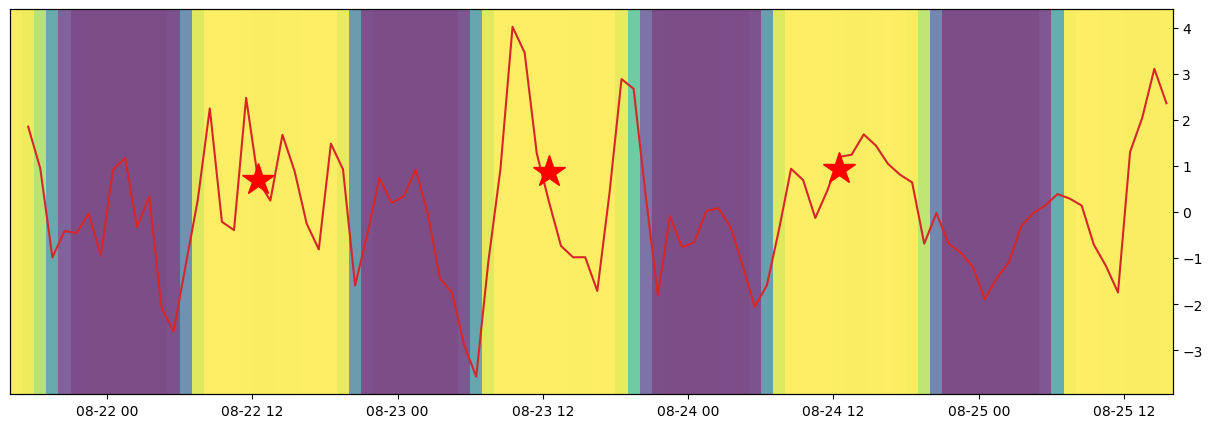

In [526]:
fig, ax2 = plt.subplots(1, 1, figsize=(15, 5))

ax2.pcolormesh(times, np.arange(5), dark.transpose(), shading='nearest', alpha=0.7);
ax2.set_yticks([])

ax = ax2.twinx()
ax.plot(times[1:], (field[1:]-field[:-1])/3600*86400/(0.5*(field[1:]+field[:-1])), color='tab:red')
ax.plot([times[it1+6], times[it1+6+24], times[it1+6+24*2]], mean_growth, 'r*', markersize=24);

In [471]:
mean_growth

[0.47217084123538094, 0.6048501065144172, 0.6640807823701338]

Morning Low on 22nd at 2024-08-22T07:30:00.000000000 of 0.40652158856391907
Evening High on 22nd at 2024-08-22T19:30:00.000000000 of 0.5783246755599976
Difference of 0.1718030869960785 mmol N /m3
Normalized Difference of 0.02869039085697932 /hr 

Morning Low on 23nd at 2024-08-22T07:30:00.000000000 of 0.40652158856391907
Evening High on 23nd at 2024-08-23T19:30:00.000000000 of 0.6160622239112854
Difference of 0.20635199546813965 mmol N /m3
Normalized Difference of 0.03329888435628763 /hr
Morning Low on 24th at 2024-08-22T07:30:00.000000000 of 0.4413413107395172
Evening High on 24th at 2024-08-23T19:30:00.000000000 of 0.6593529582023621
Difference of 0.21801164746284485 mmol N /m3
Normalized Difference of 0.03459461210663434 /hr


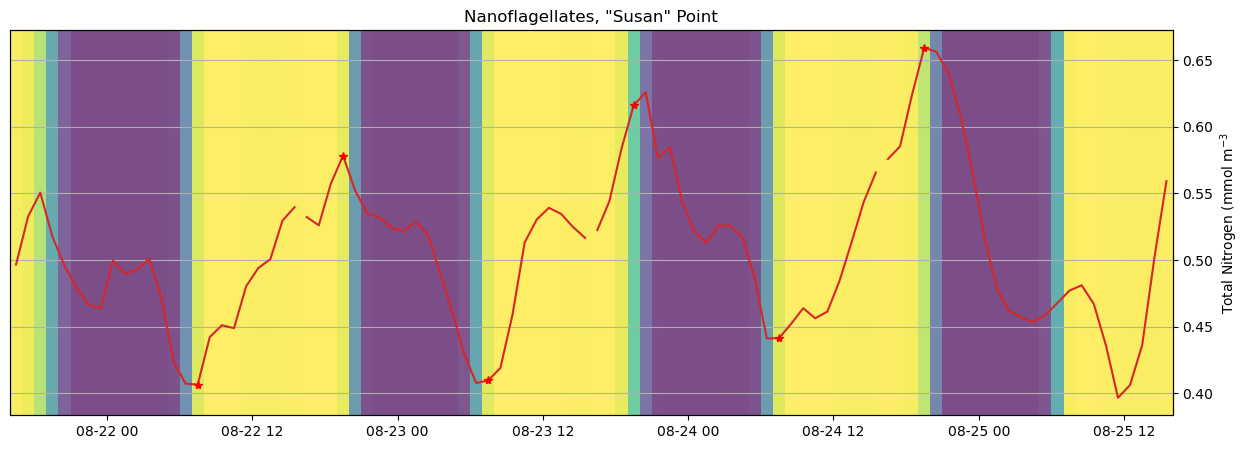

In [521]:
fig, ax2 = plt.subplots(1, 1, figsize=(15, 5))

ax2.pcolormesh(times, np.arange(5), dark.transpose(), shading='nearest', alpha=0.7);
ax2.set_yticks([])

flags = np.zeros_like(fields)
flags[1] = biol.flagellates[:, 4, si, sj]
flags[3] = biol23.flagellates[:, 4, si, sj]
flags[5] = biol24.flagellates[:, 4, si, sj]
flags[7] = biol25.flagellates[:, 4, si, sj]

ax = ax2.twinx()
ax.plot(biol.time_counter+shift_time, flags[1], c='tab:red', label='"Susan" Point')
ax.plot(biol23.time_counter+shift_time, flags[3], c='tab:red')
ax.plot(biol24.time_counter+shift_time, flags[5], c='tab:red')
ax.plot(biol25.time_counter+shift_time, flags[7], c='tab:red')
ax.grid();

ax.set_title(f'Nanoflagellates, "Susan" Point')
ax.set_ylabel('Total Nitrogen (mmol m$^{-3}$')
ax.set_xlabel('Date and Hour in 2024 in Pacific Standard Time');

it1 = 15
print (f'Morning Low on 22nd at {times[it1]} of {flags[1, it1]}')
ax.plot(times[it1], flags[1, it1], 'r*')
jt1 = 3
print (f'Evening High on 22nd at {times[jt1+24]} of {flags[3, jt1]}')
ax.plot(times[jt1+24], flags[3, jt1], 'r*')
print (f'Difference of {flags[3, jt1] - flags[1, it1]} mmol N /m3')
average1 = np.concatenate([flags[1, it1:], flags[3, :jt1+1]]).mean()
print (f'Normalized Difference of {(flags[3, jt1] - flags[1, it1])/average1/(jt1-it1+24)} /hr \n')

it2 = 15
print (f'Morning Low on 23nd at {times[it2]} of {flags[1, it2]}')
ax.plot(times[it2+24], flags[3, it2], 'r*')
jt2 = 3
print (f'Evening High on 23nd at {times[jt2+48]} of {flags[5, jt2]}')
ax.plot(times[jt2+48], flags[5, jt2], 'r*')
print (f'Difference of {flags[5, jt2] - flags[3, it2]} mmol N /m3')
average2 = np.concatenate([flags[3, it2:], flags[5, :jt2+1]]).mean()
print (f'Normalized Difference of {(flags[5, jt2] - flags[3, it2])/average2/(jt2-it2+24)} /hr')

it3 = 15
print (f'Morning Low on 24th at {times[it3]} of {flags[5, it3]}')
ax.plot(times[it3+48], flags[5, it3], 'r*')
jt3 = 3
print (f'Evening High on 24th at {times[jt3+48]} of {flags[7, jt3]}')
ax.plot(times[jt3+72], flags[7, jt3], 'r*')
print (f'Difference of {flags[7, jt3] - flags[5, it3]} mmol N /m3')
average3 = np.concatenate([flags[5, it3:], flags[7, :jt3+1]]).mean()
print (f'Normalized Difference of {(flags[7, jt3] - flags[5, it3])/average3/(jt3-it3+24)} /hr')

mean_growth_flags = [(flags[3, jt1] - flags[1, it1])/(jt1-it1+24) * 24/average1,
               (flags[5, jt2] - flags[3, it2])/(jt2-it2+24) * 24/average2,
               (flags[7, jt3] - flags[5, it3])/(jt3-it3+24) * 24/average3]

[0.6885693805675037, 0.7991732245509031, 0.8302706905592241]

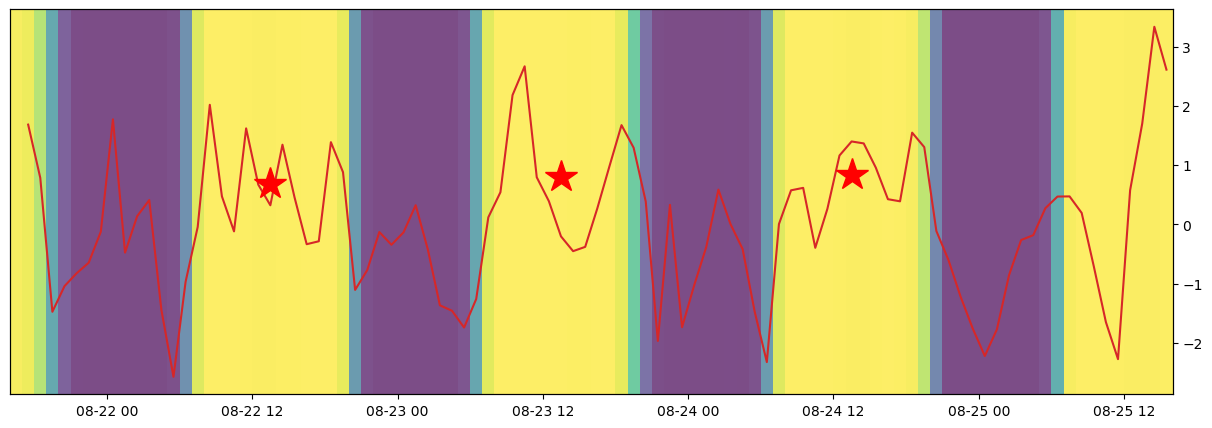

In [522]:
flag = np.concatenate([flags[1], flags[3], flags[5], flags[7]])
fig, ax2 = plt.subplots(1, 1, figsize=(15, 5))

ax2.pcolormesh(times, np.arange(5), dark.transpose(), shading='nearest', alpha=0.7);
ax2.set_yticks([])

ax = ax2.twinx()
ax.plot(times[1:], (flag[1:]-flag[:-1])/3600*86400/(0.5*(flag[1:]+flag[:-1])), color='tab:red')
ax.plot([times[it1+6], times[it1+6+24], times[it1+6+24*2]], mean_growth_flags, 'r*', markersize=24);
mean_growth_flags

In [527]:
print (np.array(mean_growth).mean(), stats.sem(np.array(mean_growth)))
print (np.array(mean_growth_flags).mean(), stats.sem(np.array(mean_growth_flags)))

0.8289742637714749 0.06703059230670841
0.7726710985592103 0.042998400454366044


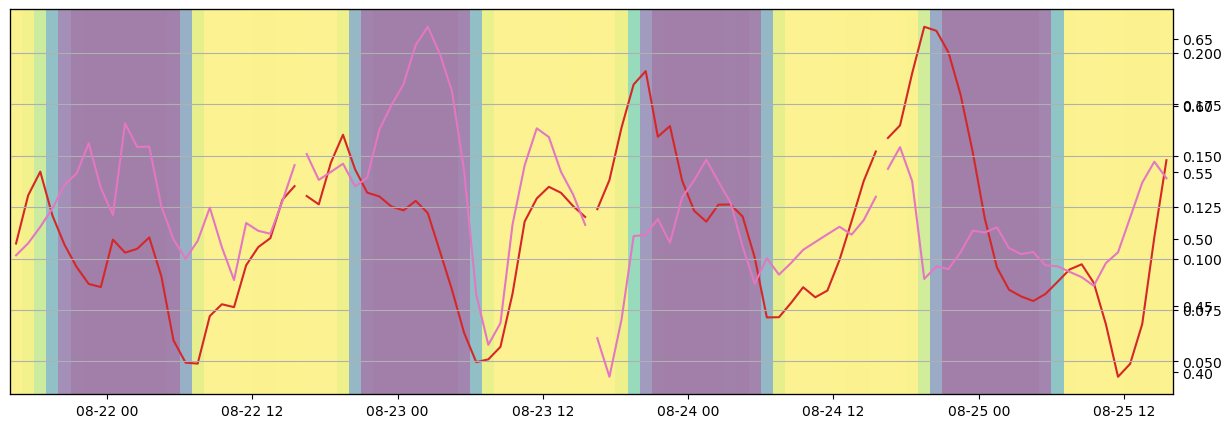

In [489]:
fig, ax2 = plt.subplots(1, 1, figsize=(15, 5))

ax2.pcolormesh(times, np.arange(5), dark.transpose(), shading='nearest', alpha=0.5);
ax2.set_yticks([])

ax = ax2.twinx()
ax.plot(biol.time_counter+shift_time, flags[1], c='tab:red', label='"Susan" Point')
ax.plot(biol23.time_counter+shift_time, flags[3], c='tab:red')
ax.plot(biol24.time_counter+shift_time, flags[5], c='tab:red')
ax.plot(biol25.time_counter+shift_time, flags[7], c='tab:red')

pon = np.zeros_like(fields)
pon[1] = biol.particulate_organic_nitrogen[:, 4, si, sj]
pon[3] = biol23.particulate_organic_nitrogen[:, 4, si, sj]
pon[5] = biol24.particulate_organic_nitrogen[:, 4, si, sj]
pon[7] = biol25.particulate_organic_nitrogen[:, 4, si, sj]

ax = ax2.twinx()
ax.plot(biol.time_counter+shift_time, pon[1], c='tab:pink', label='"Susan" Point')
ax.plot(biol23.time_counter+shift_time, pon[3], c='tab:pink')
ax.plot(biol24.time_counter+shift_time, pon[5], c='tab:pink')
ax.plot(biol25.time_counter+shift_time, pon[7], c='tab:pink')
ax.grid();



In [500]:
temperature_impact = np.zeros_like(dark[:, 0])
var = 'votemper'
temperature_impact[0:24] = temp_limit(phys[var][:, 4, si, sj])
temperature_impact[0+24:24+24] = temp_limit(phys23[var][:, 4, si, sj])
temperature_impact[0+48:24+48] = temp_limit(phys24[var][:, 4, si, sj])
temperature_impact[0+72:24+72] = temp_limit(phys25[var][:, 4, si, sj])

In [501]:
nutrient_limitation = np.zeros_like(dark[:, 0])
na, na, nutrient_limitation[0:24] = nitrogen_limit(biol.nitrate[:, 4, si, sj], biol.ammonium[:, 4, si, sj])
na, na, nutrient_limitation[0+24:24+24] = nitrogen_limit(biol23.nitrate[:, 4, si, sj], biol23.ammonium[:, 4, si, sj])
na, na, nutrient_limitation[0+48:24+48] = nitrogen_limit(biol23.nitrate[:, 4, si, sj], biol23.ammonium[:, 4, si, sj])
na, na, nutrient_limitation[0+72:24+72] = nitrogen_limit(biol23.nitrate[:, 4, si, sj], biol23.ammonium[:, 4, si, sj])

In [598]:
zgrowth = R_flag * dark[:, 0] * temperature_impact * nutrient_limitation
print (zgrowth[zgrowth > 0.7].mean(),
       stats.sem(zgrowth[zgrowth > 0.7]))

mgrowth = (flag[1:]-flag[:-1])/3600*86400/(0.5*(flag[1:]+flag[:-1]))

periods = np.zeros_like(zgrowth)
it, jt = 15+1, 3+1   # 1 shift 'cause comparing to mgrowth
periods [it:jt+24] = 1
shift = 24
periods [it+shift:jt+24+shift] = 1
shift = shift + 24
periods [it+shift:jt+24+shift] = 1

print (mgrowth[periods[1:] > 0.7].mean(),
       stats.sem(mgrowth[periods[1:] > 0.7]))

cut_length = np.zeros_like(periods)
cut_length[jt:jt+72] = 1
print (cut_length.sum())

1.2707974562521456 0.010278099671261328
0.7742723148727552 0.129872227937839
72.0


In [ ]:
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

0.001004198561646837+-0.0002933728007378328 mmol/m3 per hour, 0.4724751142288815 mmol/m3 starting value
0.001976285786897556+-0.0005773643963497445/ per hour, using mean nanoflagellate concentration
0.04743085888554135+-0.013856745512393867/ per day, using mean nanoflagellate concentration
Model growth, 0.030072242079433025+-0.0004166666666666667 per hour, 0.7217338099063926+-0.01 per day
Total loss 0.02809595629253547+-0.0009940310630164111 / hour, 0.6743029510208512+-0.02385674551239387 / day


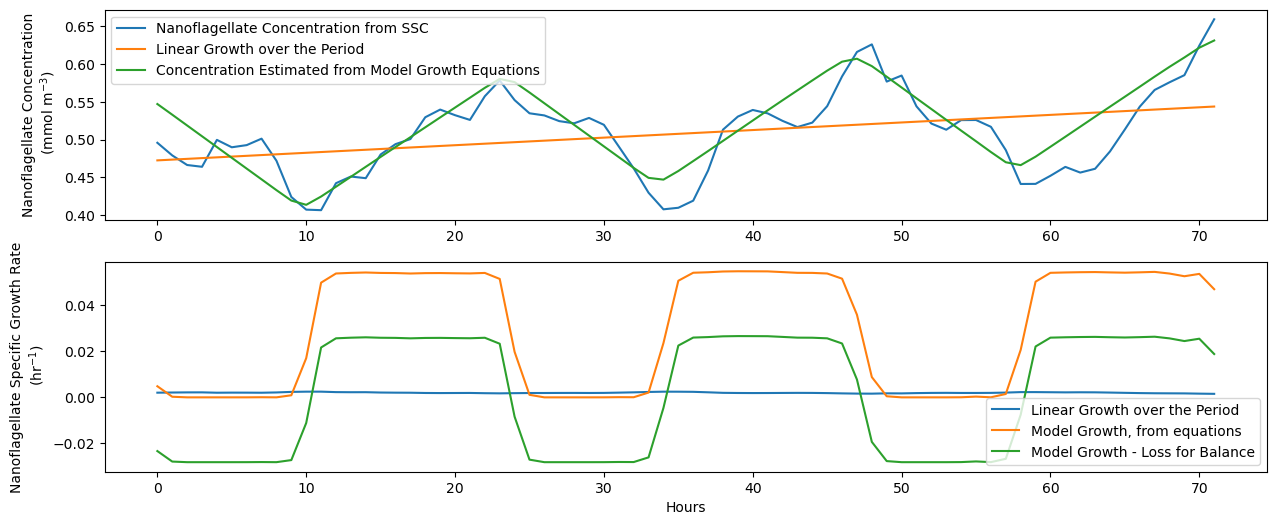

In [655]:
# Net Growth over Period (to subtract loses) 
# Working in hours
fig, axs = plt.subplots(2, 1, figsize=(15, 6))
hours = np.arange(72)
aver_flag = flag[cut_length==1].mean()
result = stats.linregress(hours, flag[cut_length==1])
ngrowth = result.slope
intercept = result.intercept
print (f'{ngrowth}+-{result.stderr} mmol/m3 per hour, {intercept} mmol/m3 starting value')
print (f'{ngrowth/aver_flag}+-{result.stderr/aver_flag}/ per hour, using mean nanoflagellate concentration')
print (f'{ngrowth/aver_flag * 24}+-{result.stderr/aver_flag * 24}/ per day, using mean nanoflagellate concentration')
axs[0].plot(hours, flag[cut_length==1], label='Nanoflagellate Concentration from SSC')
axs[0].plot(hours, intercept + hours * ngrowth, label='Linear Growth over the Period')

axs[1].plot(hours, ngrowth/flag[cut_length==1], label='Linear Growth over the Period')
#axs[0].plot(hours, periods)

model_growth = (R_flag * dark[:, 0] * temperature_impact * nutrient_limitation / 24)[cut_length==1]
mg_error = 0.01/24 # see above
print (f'Model growth, {model_growth.mean()}+-{mg_error} per hour, {model_growth.mean() * 24}+-{mg_error*24} per day')
axs[1].plot(hours, model_growth, label='Model Growth, from equations')
total_loss = model_growth.mean() - ngrowth/aver_flag
print (f'Total loss {total_loss}+-{result.stderr/aver_flag + mg_error} / hour, {total_loss*24}+-{result.stderr/aver_flag * 24 +mg_error*24} / day')
axs[1].plot(hours, model_growth - total_loss, label='Model Growth - Loss for Balance')
axs[0].plot(hours, 1.1*aver_flag+np.cumsum(aver_flag*(model_growth - total_loss)), label='Concentration Estimated from Model Growth Equations');

axs[0].set_ylabel('Nanoflagellate Concentration\n (mmol m$^{-3}$)')
axs[1].set_ylabel('Nanoflagellate Specific Growth Rate\n (hr$^{-1}$)')
axs[1].set_xlabel('Hours')
axs[0].legend();
axs[1].legend();

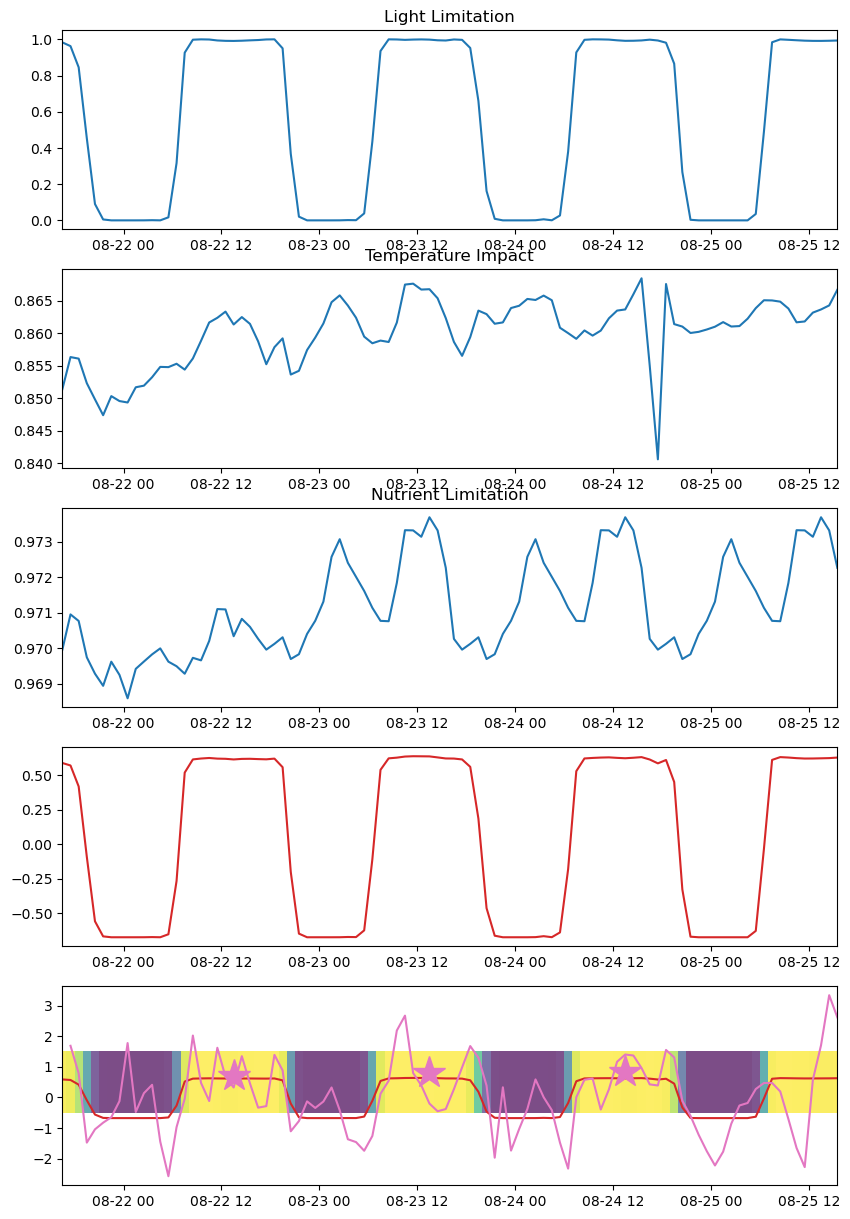

In [660]:
# Expected Flagellate Growth Rate
R_flag = 1.8e-5 * 86400
# loss calculated above
total_loss_pd = total_loss * 24 
fig, axs = plt.subplots(5, 1, figsize=(10, 15))
axs[0].plot(times, dark[:, 0])
axs[0].set_title('Light Limitation')
axs[1].plot(times, temperature_impact)
axs[1].set_title('Temperature Impact')
axs[2].plot(times, nutrient_limitation)
axs[2].set_title('Nutrient Limitation')

axs[3].plot(times, R_flag * dark[:, 0] * temperature_impact * nutrient_limitation
            - total_loss_pd, color='tab:red')
#axs[3].set_ylim(0.5, 0.85);
it1 = 15
#axs[3].plot([times[it1+6], times[it1+6+24], times[it1+6+24*2]], mean_growth_flags, '*', 
#            color='tab:pink', markersize=24);
#axs[3].plot([times[0], times[-1]], [0.7, 0.7], '-', color='grey')

axs[4].pcolormesh(times, np.arange(2), dark[:, 0:2].transpose(), shading='nearest', alpha=0.7);
axs[4].plot(times, R_flag * dark[:, 0] * temperature_impact * nutrient_limitation
            - total_loss_pd, color='tab:red')
axs[4].plot(times[1:], (flag[1:]-flag[:-1])/3600*86400/(0.5*(flag[1:]+flag[:-1])), color='tab:pink');
axs[4].plot([times[it1+6], times[it1+6+24], times[it1+6+24*2]], mean_growth_flags, '*', 
            color='tab:pink', markersize=24);

for ax in axs:
    ax.set_xlim(times[0], times[-1])

* The growth rate of nanoflagellates from the model is 0.77+-0.13 per day (note, noisier but similar using PON)
* The growth rate from the formulas in the model is 0.72 /day when averaged over a day.
* The growth rate, just in the day is 1.27+-0.01 / day with a loss rate of 0.67+-0.03 / day for a during day growth rate of 0.60+-0.04 /day whereas the growth rate from the observations is 1.0 /day

* As light and nutrients are not limiting, this analysis would say that the growth rate of flagellates in the model is low by at least 30%.